# Extracción de Entidades

En este caso, buscamos analizar otro posible modelo de NLP que esté disponible en Hugging-Face, y que podría ser usado con nuestro dataset para realizar otro tipo de tarea. Para ello, vamos a utilizar embeddings por subtoken (aplicando last-4-layers mean) generados en  con el modelo `boltuix NeuroBERT-NER`, aplicando la cabeza de clasificación de NER (la capa lineal del modelo) sobre cada embedding de subtoken para obtener las etiquetas BIO o *logits* y luego agrupar spans.

In [12]:
from transformers import AutoModelForTokenClassification, AutoConfig, AutoTokenizer
import pandas as pd

model_name = "boltuix/NeuroBERT-NER"
config = AutoConfig.from_pretrained(model_name)
id2label = config.id2label
label2id = config.label2id

print(f"Total de etiquetas: {len(id2label)}")
print("=" * 25)
print(id2label)

Total de etiquetas: 37
{0: 'B-CARDINAL', 1: 'B-DATE', 2: 'B-EVENT', 3: 'B-FAC', 4: 'B-GPE', 5: 'B-LANGUAGE', 6: 'B-LAW', 7: 'B-LOC', 8: 'B-MONEY', 9: 'B-NORP', 10: 'B-ORDINAL', 11: 'B-ORG', 12: 'B-PERCENT', 13: 'B-PERSON', 14: 'B-PRODUCT', 15: 'B-QUANTITY', 16: 'B-TIME', 17: 'B-WORK_OF_ART', 18: 'I-CARDINAL', 19: 'I-DATE', 20: 'I-EVENT', 21: 'I-FAC', 22: 'I-GPE', 23: 'I-LANGUAGE', 24: 'I-LAW', 25: 'I-LOC', 26: 'I-MONEY', 27: 'I-NORP', 28: 'I-ORDINAL', 29: 'I-ORG', 30: 'I-PERCENT', 31: 'I-PERSON', 32: 'I-PRODUCT', 33: 'I-QUANTITY', 34: 'I-TIME', 35: 'I-WORK_OF_ART', 36: 'O'}


Vamos a cargar los tokens que generamos con el mismo modelo en la segunda entrega para la deteccion de entidades.

In [13]:
tokens = pd.read_parquet("../Representacion_del_lenguaje/processed_data/fin-bertTokenized.parquet")
article_text = tokens.loc[:,"article_text"]
input_ids = tokens.loc[:,"input_ids"]
attention_mask = tokens.loc[:,"attention_mask"]
print(tokens.head(3))

                                        article_text  \
0  The UK jobs market continues to show signs of ...   
1  New data from the Department from Work and Pen...   
2  Asking for workplace accommodations is often e...   

                                           input_ids  \
0  [101, 1996, 2866, 5841, 3006, 4247, 2000, 2265...   
1  [101, 2047, 2951, 2013, 1996, 2533, 2013, 2147...   
2  [101, 4851, 2005, 16165, 26167, 2003, 2411, 60...   

                                      attention_mask  
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...  
1  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...  
2  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...  


In [14]:
import torch

try:
    # Convertir las listas a tensores de PyTorch
    t_input_ids = torch.tensor(input_ids)
    t_attention_mask = torch.tensor(attention_mask)

    print("Datos cargados con fastparquet.")
    print("input_ids:\n", t_input_ids)
    print("attention_mask:\n", t_attention_mask)
except Exception as e:
    print(f"Error al usar fastparquet: {e}")

Datos cargados con fastparquet.
input_ids:
 tensor([[  101,  1996,  2866,  ...,     0,     0,     0],
        [  101,  2047,  2951,  ...,  2077,  2037,   102],
        [  101,  4851,  2005,  ...,  5005,  1011,   102],
        ...,
        [  101,  7211,  1006,  ...,     0,     0,     0],
        [  101,  5148,  1521,  ..., 29336,  5369,   102],
        [  101,  2054,  2064,  ...,  2028,  1011,   102]])
attention_mask:
 tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])


In [15]:
model = AutoModelForTokenClassification.from_pretrained(model_name,
                                                        num_labels=len(id2label),
                                                        id2label=id2label,
                                                        label2id=label2id)

El modelo  destaca por identificar 36 tipos de entidades (por ejemplo, personas, lugares, organizaciones, fechas, dinero) en texto en inglés.

Para esta tarea recuperamos *outputs.logits* directamente, sin aplicar el layer pooling, ya que el objetivo es usar la cabeza NER original.

In [22]:
sample_text = article_text[0]
sample_input_ids = t_input_ids[0].unsqueeze(0) # Añadir dimensión batch
sample_attention_mask = t_attention_mask[0].unsqueeze(0) # Añadir dimensión batch

with torch.no_grad():
    outputs = model(input_ids=sample_input_ids, attention_mask=sample_attention_mask)

predictions = outputs.logits.argmax(dim=-1)[0].cpu().numpy()
tokens = AutoTokenizer.from_pretrained("boltuix/NeuroBERT-NER").convert_ids_to_tokens(sample_input_ids[0])
word_ids = sample_input_ids[0].cpu().numpy()

Dado que el conjunto de datos no incluye anotaciones de entidades de referencia, evaluaremos el modelo NER de forma cualitativa, analizando los resultados sobre un subconjunto de noticias, evaluando la precisión, cobertura y coherencia de las entidades detectadas.

In [23]:
print("=" * 60)
print("ENTIDADES DETECTADAS (Etiquetas B- e I-)")
print("=" * 60)

entity_count = 0
tags = []
for idx, (token, pred_id) in enumerate(zip(tokens, predictions)):
    label = model.config.id2label[pred_id]
    tags.append(label)
    
    # Solo mostrar tokens que tienen etiquetas B- o I- (entidades)
    if label.startswith('B-') or label.startswith('I-'):
        print(f"Token: {token:20} | Label: {label}")
        entity_count += 1

print("=" * 60)
print(f"Total de tokens clasificados como entidad: {entity_count}")
print("=" * 60)


ENTIDADES DETECTADAS (Etiquetas B- e I-)
Token: uk                   | Label: B-ORG
Token: the                  | Label: B-DATE
Token: autumn               | Label: B-DATE
Token: next                 | Label: I-DATE
Token: month                | Label: I-DATE
Token: ##s                  | Label: B-ORG
Token: tuesday              | Label: B-DATE
Token: the                  | Label: B-DATE
Token: three                | Label: B-DATE
Token: months               | Label: I-DATE
Token: august               | Label: B-DATE
Token: 4                    | Label: B-PERCENT
Token: .                    | Label: B-PERCENT
Token: 7                    | Label: B-PERCENT
Token: %                    | Label: I-PERCENT
Token: 4                    | Label: B-PERCENT
Token: .                    | Label: B-PERCENT
Token: 8                    | Label: B-PERCENT
Token: %                    | Label: I-PERCENT
Token: may                  | Label: B-DATE
Token: july                 | Label: B-DATE
Token: 4     

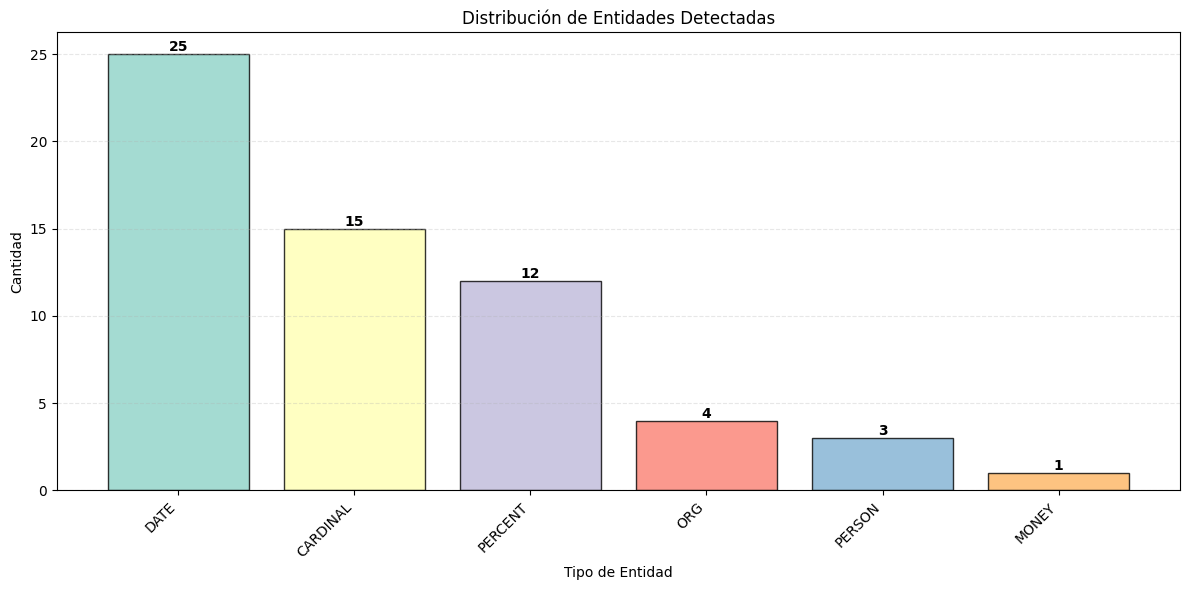

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def extract_entities(tokens, tags):
    entities, start, label = [], None, None
    for i, tag in enumerate(tags):
        if tag.startswith("B-"):
            if start is not None:
                entities.append((label, " ".join(tokens[start:i])))
            start, label = i, tag[2:]
        elif tag == "O" and start is not None:
            entities.append((label, " ".join(tokens[start:i])))
            start, label = None, None
    if start is not None:
        entities.append((label, " ".join(tokens[start:])))
    return entities

# Extraer y contar entidades
ents = extract_entities(tokens, tags)
df_counts = pd.DataFrame(Counter([lab for lab, _ in ents]).items(), 
                         columns=['Etiqueta', 'Cantidad']).sort_values('Cantidad', ascending=False)


fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(df_counts['Etiqueta'], df_counts['Cantidad'], 
              color=plt.cm.Set3(range(len(df_counts))), edgecolor='black', alpha=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

ax.set(xlabel='Tipo de Entidad', ylabel='Cantidad', 
       title='Distribución de Entidades Detectadas')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Uno de los errores más notables en la asignación de etiquetas BIO es la confusion en la distinción entre los prefijos B- (Beginning) e I- (Inside). La mayora de veces el modelo se equivoca etiquetando los primeros tokens de una entidad compuesta como B, sol marcando con I el último token. Esto afecta principalmente a entidades formadas por varias partes, como fechas, cantidades numéricas o porcentajes, y quiza por eso este tipo de entidades aparece con mayor frecuencia en los resultados, aunque no siempre esten bien detectadas. Este patrón sugiere que el modelo tiene dificultades para mantener la coherencia interna de entidades largas o de varios tokens.